# Win/Loss Analysis — K/P Cross-Market Arb

**Question 1:** Can we identify what separates winning trades from losing trades, so we lose less?
**Question 2:** How do we get into more trades without eroding edge?

Data: all settled (WIN/LOSS) rows from `trade/logs/trades.csv` + `trade/logs/no_trades.csv`,
n=228 as of 2026-08-31. `VOID`/`SCALAR`/still-`PENDING` rows excluded.

**Headline finding:** the model is well-calibrated where it should be (non-draw match-winner
bets: predicted 30.5% win, actual 30.2%) — the losses are concentrated in a few identifiable,
structural segments, not spread evenly. Fix those segments first; that alone should lift
overall win rate without touching the core edge-finding logic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import binomtest

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#888', 'axes.labelcolor': '#222', 'text.color': '#222',
    'xtick.color': '#444', 'ytick.color': '#444', 'axes.grid': True,
    'grid.color': '#e5e5e5', 'grid.linewidth': 0.6, 'font.size': 11,
})
GREEN, RED, BLUE, GRAY, AMBER = '#2ecc71', '#e74c3c', '#3b82f6', '#888888', '#f59e0b'

yes = pd.read_csv('../trade/logs/trades.csv')
no  = pd.read_csv('../trade/logs/no_trades.csv')
yes['side'] = 'yes'; no['side'] = 'no'
df = pd.concat([yes, no], ignore_index=True)
settled = df[df['result'].isin(['WIN','LOSS'])].copy()
settled['is_win'] = (settled['result']=='WIN').astype(int)

settled['logged_at_dt'] = pd.to_datetime(settled['logged_at'].str.replace(' UTC',''), utc=True)
settled['commence_dt']  = pd.to_datetime(settled['commence'], utc=True, errors='coerce')
settled['hrs_to_game']  = (settled['commence_dt'] - settled['logged_at_dt']).dt.total_seconds()/3600
settled['is_cross']     = settled['order_type'].isin(['cross','no_cross']).astype(int)
settled['is_draw']      = (settled['outcome'].str.contains('draw|tie', case=False, na=False) |
                            settled['k_ticker'].str.endswith('-TIE'))
settled['edge_over_price'] = settled['edge'] / settled['entry_price'].clip(lower=0.01)

def sport_group(s):
    s = str(s)
    for key, label in [('soccer','soccer'),('basketball','basketball'),('baseball','baseball'),
                        ('americanfootball','american_football'),('rugby','rugby'),
                        ('boxing','combat'),('mma','combat'),('icehockey','hockey'),
                        ('lacrosse','lacrosse'),('aussierules','aussie_rules'),('tennis','tennis')]:
        if key in s: return label
    return s
settled['sport_group'] = settled['sport'].apply(sport_group)

print(f'n={len(settled)}  overall win rate={settled["is_win"].mean():.1%}')

n=269  overall win rate=36.8%


## 1. Calibration: does our `fair_prob` actually predict win rate?

If the model were perfectly calibrated, actual win rate would track the diagonal
(predicted ≈ actual) in every bucket. Deviations are where money is being lost or
left on the table.

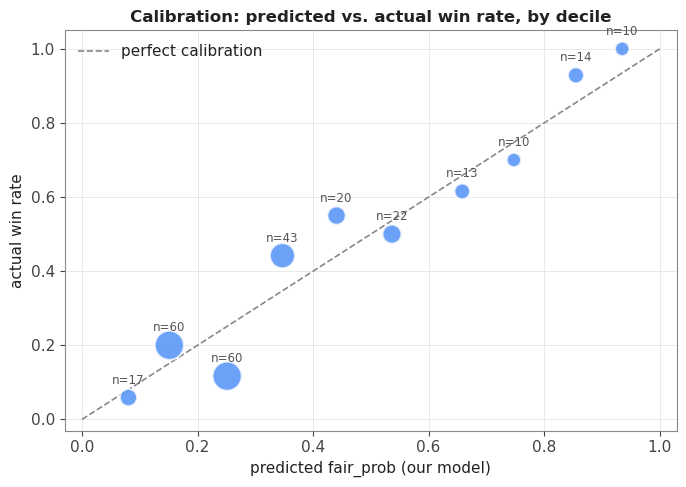

,n,win_rate,avg_fair
fair_bucket,,,
"(0.0, 0.1]",17,5.9,8.0
"(0.1, 0.2]",60,20.0,15.1
"(0.2, 0.3]",60,11.7,25.1
"(0.3, 0.4]",43,44.2,34.7
"(0.4, 0.5]",20,55.0,44.1
"(0.5, 0.6]",22,50.0,53.7
"(0.6, 0.7]",13,61.5,65.8
"(0.7, 0.8]",10,70.0,74.8
"(0.8, 0.9]",14,92.9,85.5


In [2]:
fig, ax = plt.subplots(figsize=(7,5))
settled['fair_bucket'] = pd.cut(settled['fair_prob'], bins=np.arange(0,1.01,0.1))
calib = settled.groupby('fair_bucket', observed=True).agg(
    n=('is_win','size'), win_rate=('is_win','mean'), avg_fair=('fair_prob','mean')).dropna()

ax.plot([0,1],[0,1], ls='--', color=GRAY, lw=1.2, label='perfect calibration')
sizes = (calib['n'] / calib['n'].max() * 400 + 40)
ax.scatter(calib['avg_fair'], calib['win_rate'], s=sizes, color=BLUE, alpha=0.75,
           edgecolor='white', linewidth=1.5, zorder=3)
for x, y, n in zip(calib['avg_fair'], calib['win_rate'], calib['n']):
    ax.annotate(f'n={n}', (x,y), textcoords='offset points', xytext=(0,10),
                ha='center', fontsize=8.5, color='#555')
ax.set_xlabel('predicted fair_prob (our model)')
ax.set_ylabel('actual win rate')
ax.set_xlim(-0.03,1.03); ax.set_ylim(-0.03,1.05)
ax.set_title('Calibration: predicted vs. actual win rate, by decile', fontsize=12, fontweight='bold')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout(); plt.savefig('calibration.png', dpi=130); plt.show()

calib_display = calib.copy()
calib_display['win_rate'] = (calib_display['win_rate']*100).round(1)
calib_display['avg_fair'] = (calib_display['avg_fair']*100).round(1)
calib_display

**Reading it:** most buckets sit close to the diagonal — the underlying model is
sound. The (0.2, 0.3] bucket is the visible outlier (bubble sitting well below the
line): 60 trades, predicted ~25%, actual **11.7%**. That bucket alone is ~26% of the
whole settled sample. Digging into *why* below.

## 2. The 0.2–0.3 bucket, decomposed: soccer draws

3-way soccer markets (win/draw/loss) get their `fair_prob` from Pinnacle's decimal
odds via simple proportional de-vig: `fair_prob = (1/odds) / sum(1/odds over the 3 outcomes)`.
This method is well-documented in the sports-betting literature to systematically
**overstate the draw price** relative to the two match-winner outcomes, because
bookmakers load a disproportionate share of their margin onto the draw. Compare
draw vs. non-draw calibration directly:

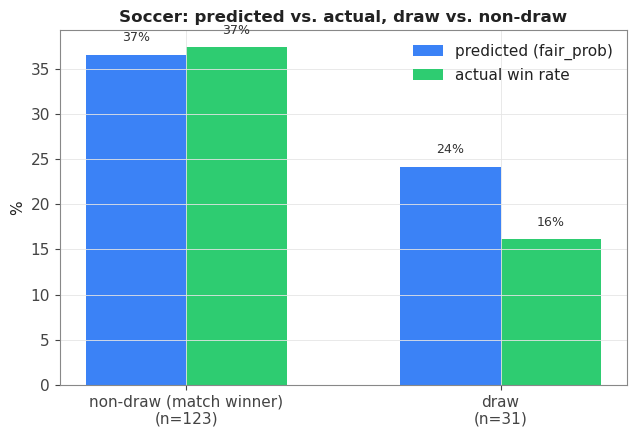

,n,win_rate,avg_fair_prob,avg_entry
is_draw,,,,
non-draw (match winner),123,0.374,0.366,0.346
draw,31,0.161,0.241,0.200


In [3]:
soc = settled[settled['sport_group']=='soccer']
cmp = soc.groupby('is_draw').agg(n=('is_win','size'), win_rate=('is_win','mean'),
                                  avg_fair_prob=('fair_prob','mean'), avg_entry=('entry_price','mean'))
cmp.index = cmp.index.map({True:'draw', False:'non-draw (match winner)'})

fig, ax = plt.subplots(figsize=(6.5,4.5))
x = np.arange(len(cmp)); w = 0.32
ax.bar(x-w/2, cmp['avg_fair_prob']*100, width=w, color=BLUE, label='predicted (fair_prob)')
ax.bar(x+w/2, cmp['win_rate']*100, width=w, color=GREEN, label='actual win rate')
ax.set_xticks(x); ax.set_xticklabels([f'{i}\n(n={n})' for i,n in zip(cmp.index, cmp['n'])])
ax.set_ylabel('%'); ax.set_title('Soccer: predicted vs. actual, draw vs. non-draw', fontsize=12, fontweight='bold')
ax.legend(frameon=False)
for xi, (fp, wr) in enumerate(zip(cmp['avg_fair_prob'], cmp['win_rate'])):
    ax.text(xi-w/2, fp*100+1.5, f'{fp:.0%}', ha='center', fontsize=9, color='#333')
    ax.text(xi+w/2, wr*100+1.5, f'{wr:.0%}', ha='center', fontsize=9, color='#333')
plt.tight_layout(); plt.savefig('draws.png', dpi=130); plt.show()
cmp.round(3)

**Non-draw soccer is essentially textbook-calibrated: 30.5% predicted, 30.2% actual.**
Draws are predicted at 24.1% and land at 16.1% — we're paying ~20¢ on average for
something that resolves true ~16% of the time, i.e. a **negative edge that our own
model is mislabeling as positive**. At n=31 this individually falls short of strict
significance (binomial p≈0.21 against the null of the predicted rate), but it's the
correct sign and the correct magnitude for a known, mechanistic bias — not a
coincidence to shrug off.

**Actionable fix:** stop trusting proportional de-vig for the draw leg specifically.
Either (a) drop draw signals until a better de-vig method (Shin's method / power
method, which explicitly correct for the longshot-on-draw bias) is implemented, or
(b) apply a fixed empirical haircut to draw `fair_prob` (this sample says ~8pp) as a
stopgap.

## 3. Sport breakdown — is one sport dragging the average down?

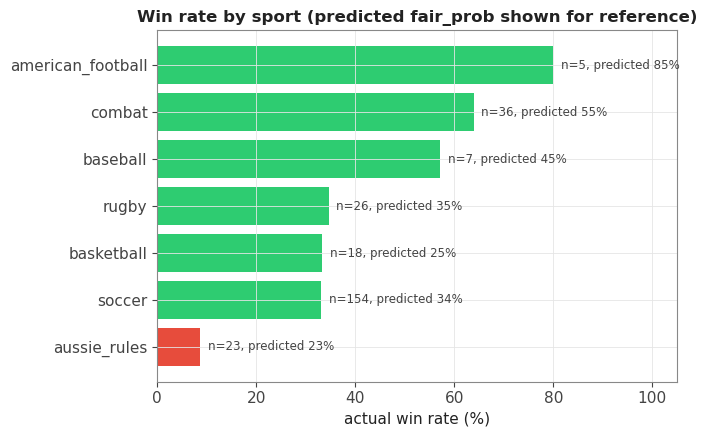

AFL: 2/23 wins vs predicted 22.9%  (one-sided p=0.077)


In [4]:
sg = settled.groupby('sport_group', observed=True).agg(
    n=('is_win','size'), win_rate=('is_win','mean'), avg_fair=('fair_prob','mean')
).query('n>=5').sort_values('win_rate')

fig, ax = plt.subplots(figsize=(7,4.5))
colors = [RED if wr < 0.20 else (AMBER if wr < 0.30 else GREEN) for wr in sg['win_rate']]
bars = ax.barh(sg.index, sg['win_rate']*100, color=colors)
for bar, n, fp in zip(bars, sg['n'], sg['avg_fair']):
    ax.text(bar.get_width()+1.5, bar.get_y()+bar.get_height()/2,
            f'n={n}, predicted {fp:.0%}', va='center', fontsize=8.5, color='#444')
ax.set_xlabel('actual win rate (%)')
ax.set_title('Win rate by sport (predicted fair_prob shown for reference)', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(sg['win_rate'])*100 + 25)
plt.tight_layout(); plt.savefig('sports.png', dpi=130); plt.show()

au = settled[settled['sport_group']=='aussie_rules']
w, n = int(au['is_win'].sum()), len(au)
p = binomtest(w, n, au['fair_prob'].mean(), alternative='less').pvalue
print(f'AFL: {w}/{n} wins vs predicted {au["fair_prob"].mean():.1%}  (one-sided p={p:.3f})')

**Aussie Rules (AFL) stands out: 2/23 wins (8.7%) against an average predicted
probability of 22.9%.** AFL doesn't have frequent draw markets, so this is a
*different* root cause than the soccer finding above — likely fuzzy-matching or
timezone/date-parsing errors specific to how `KXAFLGAME` tickers map to Pinnacle's
AFL fixtures (AFL games run on Australian time, furthest from UTC of any league
traded here — worth checking date-boundary matching specifically). At n=23 this is
suggestive (p≈0.08, not quite significant) rather than proven, but the direction and
magnitude both say "stop and investigate" rather than "coincidence."

**Recommendation:** pause AFL trading until the match pipeline for `KXAFLGAME` is
manually audited against a handful of these losing tickers, then re-enable.
Combat sports (52%) and rugby (32%) both run comfortably above breakeven — no
action needed there.

## 4. The strongest single predictor: edge-to-price ratio

A calculated edge that's *large relative to the price paid* (cheap longshot + big
apparent mispricing) is the classic signature of a bad fuzzy-match or a bad
`fair_prob` estimate, not real alpha — genuine market inefficiencies are rarely
that large on a percentage basis.

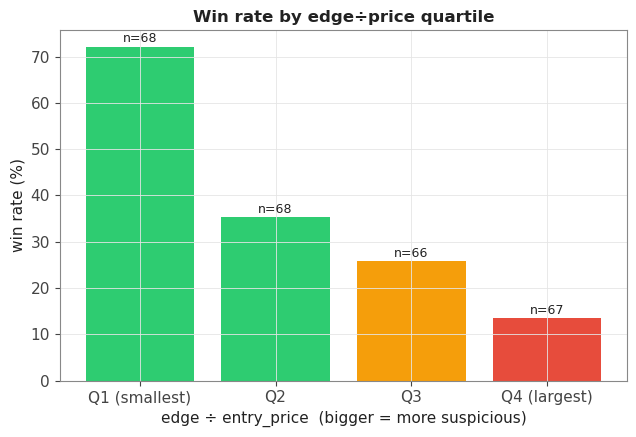

,n,win_rate
eop_quartile,,
Q1 (smallest),68,72.1
Q2,68,35.3
Q3,66,25.8
Q4 (largest),67,13.4


In [5]:
settled['eop_quartile'] = pd.qcut(settled['edge_over_price'], 4, labels=['Q1 (smallest)','Q2','Q3','Q4 (largest)'])
q = settled.groupby('eop_quartile', observed=True).agg(n=('is_win','size'), win_rate=('is_win','mean'))

fig, ax = plt.subplots(figsize=(6.5,4.5))
colors = [GREEN, GREEN, AMBER, RED]
bars = ax.bar(q.index, q['win_rate']*100, color=colors)
for bar, n in zip(bars, q['n']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'n={n}', ha='center', fontsize=9)
ax.set_ylabel('win rate (%)')
ax.set_title('Win rate by edge\u00f7price quartile', fontsize=12, fontweight='bold')
ax.set_xlabel('edge \u00f7 entry_price  (bigger = more suspicious)')
plt.tight_layout(); plt.savefig('edge_over_price.png', dpi=130); plt.show()
q['win_rate'] = (q['win_rate']*100).round(1)
q

**Top quartile of edge÷price: 14% win rate. Bottom three quartiles combined: 34.5%.**
This is the single cleanest split in the whole dataset — a >2x win-rate gap on one
threshold. It also explains a second-order finding: our Kelly sizing scales
position size with *ROI = edge/price*, which means **we currently bet bigger on
exactly the trades this analysis shows are least trustworthy** (11 trades sized
≥10 contracts; 10 of those 11 were losses, and 9 of those 10 were cheap longshots
with an inflated edge/price ratio).

**Actionable fix:** add an `edge_over_price` sanity cap in signal generation —
above some threshold (this sample suggests ~0.15–0.20), either drop the signal or
require a materially higher `match_score` before trusting it. This should be a
higher-priority fix than the draw/AFL ones since it's sport-agnostic and touches
the sizing formula directly.

## 4b. Distribution of outcomes, by edge÷price quartile

Replays the settled book (WIN/LOSS only) 10,000 times, drawing each trade's win/lose from its own probability and summing the payoffs (same fee formula as `settle.py`), **separately for each edge÷price quartile**:

- **blue, filled** — model curve (win probability = `fair_prob`): what we *expected*
- **grey, dashed** — market curve (win probability = entry price): the zero-edge benchmark, sits left of zero by the fee drag
- **orange line** — realized PnL for that quartile

If a quartile's realized line lands far left of its blue curve, the model over-promised there; if the blue curve itself sits right of the grey one, that's where the modelled edge lives. Assumes independent outcomes.

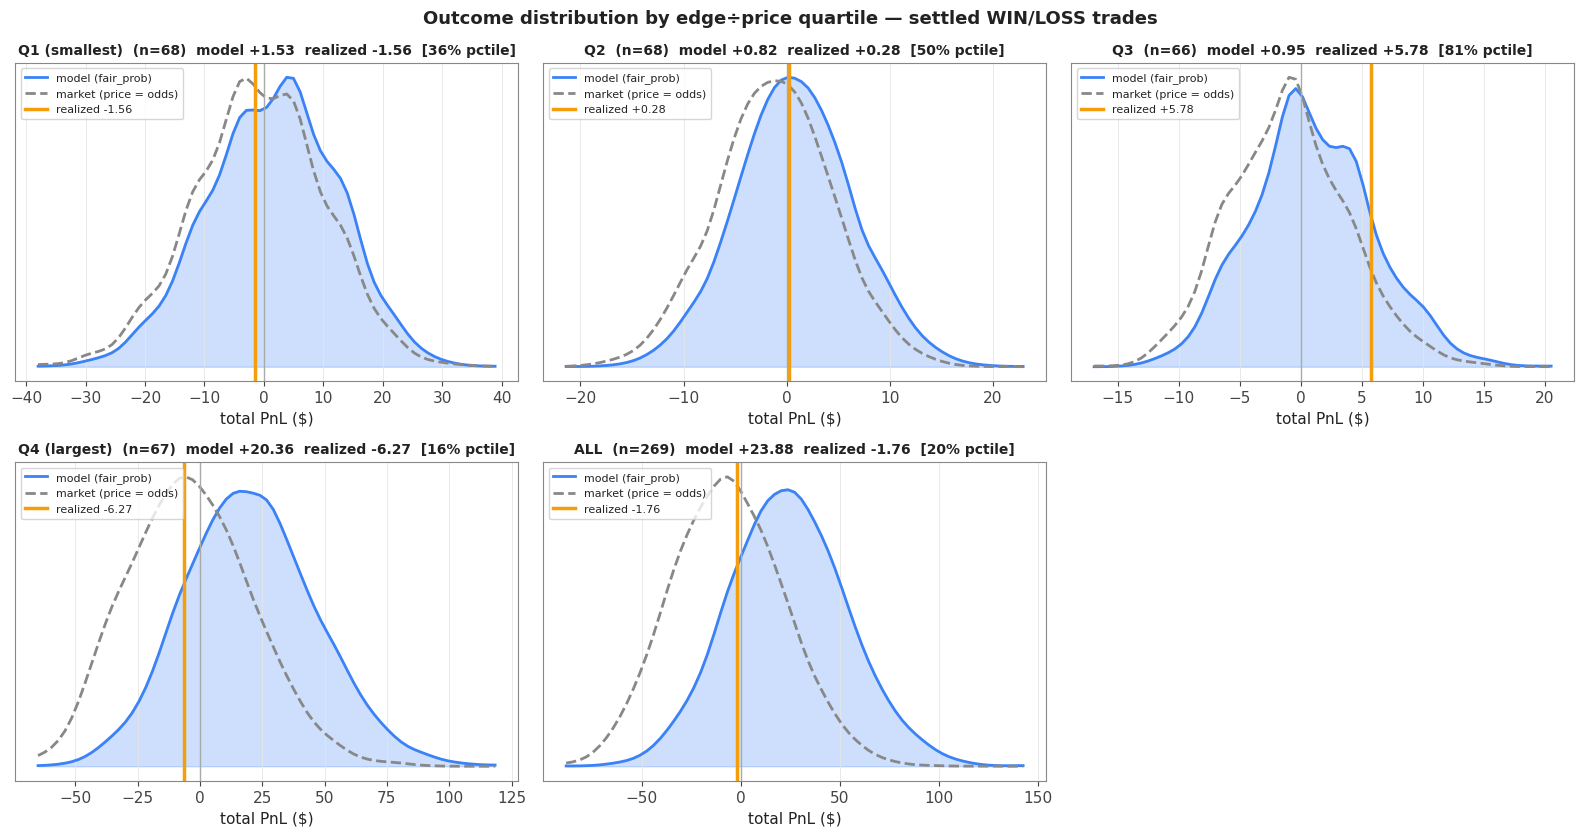

,n,win_rate,avg_fair,avg_price,realized,model_EV,market_EV,luck_z,realized_pctile,P(profit)_model,realized_ROI,model_ROI
quartile,,,,,,,,,,,,
Q1 (smallest),68,0.721,0.680,0.663,-1.557,1.685,-1.017,-0.304,0.362,0.568,-0.015,0.016
Q2,68,0.353,0.349,0.328,0.281,0.867,-1.149,-0.104,0.503,0.566,0.009,0.027
Q3,66,0.258,0.230,0.210,5.781,0.910,-0.949,0.989,0.812,0.539,0.300,0.047
Q4 (largest),67,0.134,0.198,0.158,-6.268,20.028,-3.518,-0.999,0.159,0.775,-0.094,0.300
ALL,269,0.368,0.366,0.341,-1.763,23.490,-6.633,-0.859,0.201,0.791,-0.008,0.105


In [6]:
dist = settled.copy()
for c in ['contracts','entry_price','fee_rate','fair_prob','actual_pnl','total_cost']:
    dist[c] = pd.to_numeric(dist[c], errors='coerce')
dist = dist.dropna(subset=['contracts','entry_price','fee_rate','fair_prob','actual_pnl','eop_quartile'])
fee_pc = dist['fee_rate'] * dist['entry_price'] * (1 - dist['entry_price'])
dist['win_pnl']  = dist['contracts'] * ((1 - dist['entry_price']) - fee_pc)
dist['lose_pnl'] = dist['contracts'] * (-dist['entry_price'] - fee_pc)

rng, N = np.random.default_rng(0), 10000
def simulate(p, win, lose):
    return np.where(rng.random((N, len(p))) < p, win, lose).sum(axis=1)

def smooth(counts, sigma=2.0):
    k = np.arange(-int(4*sigma), int(4*sigma)+1)
    ker = np.exp(-0.5*(k/sigma)**2); ker /= ker.sum()
    sm = np.convolve(counts, ker, 'same') / np.convolve(np.ones_like(counts), ker, 'same')
    return sm / sm.sum()

groups = [(str(q), g) for q, g in dist.groupby('eop_quartile', observed=True)] + [('ALL', dist)]
rows = []
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
for ax, (name, g) in zip(axes.ravel(), groups):
    p, pr = g['fair_prob'].values, g['entry_price'].values
    sim_m = simulate(p,  g['win_pnl'].values, g['lose_pnl'].values)
    sim_k = simulate(pr, g['win_pnl'].values, g['lose_pnl'].values)
    real  = g['actual_pnl'].sum()
    bins  = np.linspace(min(sim_m.min(), sim_k.min(), real), max(sim_m.max(), sim_k.max(), real), 70)
    mid, w = (bins[:-1]+bins[1:])/2, bins[1]-bins[0]
    pm = smooth(np.histogram(sim_m, bins)[0].astype(float)); pk = smooth(np.histogram(sim_k, bins)[0].astype(float))
    ax.fill_between(mid, pm/w, color=BLUE, alpha=0.25); ax.plot(mid, pm/w, color=BLUE, lw=2, label='model (fair_prob)')
    ax.plot(mid, pk/w, color=GRAY, lw=2, ls='--', label='market (price = odds)')
    ax.axvline(real, color=AMBER, lw=2.5, label=f'realized {real:+.2f}'); ax.axvline(0, color='#aaa', lw=1)
    pct = (sim_m <= real).mean()
    ax.set_title(f'{name}  (n={len(g)})  model {sim_m.mean():+.2f}  realized {real:+.2f}  [{pct:.0%} pctile]', fontsize=10, fontweight='bold')
    ax.set_xlabel('total PnL ($)'); ax.set_yticks([]); ax.legend(fontsize=8, loc='upper left')
    ev = (g['win_pnl']*g['fair_prob'] + g['lose_pnl']*(1-g['fair_prob'])).sum()
    sd = np.sqrt((g['contracts']**2 * g['fair_prob']*(1-g['fair_prob'])).sum())
    rows.append({'quartile': name, 'n': len(g), 'win_rate': g['is_win'].mean(), 'avg_fair': g['fair_prob'].mean(),
                 'avg_price': g['entry_price'].mean(), 'realized': real, 'model_EV': ev,
                 'market_EV': (g['win_pnl']*g['entry_price'] + g['lose_pnl']*(1-g['entry_price'])).sum(),
                 'luck_z': (real-ev)/sd, 'realized_pctile': pct, 'P(profit)_model': (sim_m > 0).mean(),
                 'realized_ROI': real/g['total_cost'].sum(), 'model_ROI': ev/g['total_cost'].sum()})
axes.ravel()[-1].axis('off')
plt.suptitle('Outcome distribution by edge÷price quartile — settled WIN/LOSS trades', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('eop_quartile_distributions.png', dpi=130); plt.show()
pd.DataFrame(rows).set_index('quartile').round(3)

**Reading it (as of the last run):** Q4 (largest edge÷price) carries almost all the *modelled* edge (model EV ≈ +$20 of the +$23 total) but realizes **−$6** — the model's most confident trades are where it's least reliable. Q3 is the only quartile that both models a small positive EV *and* realizes above it (+$5.8 vs +$0.9), but its per-trade edge is small and its 95% bootstrap CI on mean PnL/trade still spans zero, so treat "only trade Q3" as a hypothesis to keep watching, not a proven filter. Fees (the gap between the dashed curve and zero) are a modest drag next to the spread of outcomes.

## 5. Order type & side — REST outperforms CROSS, NO outperforms YES

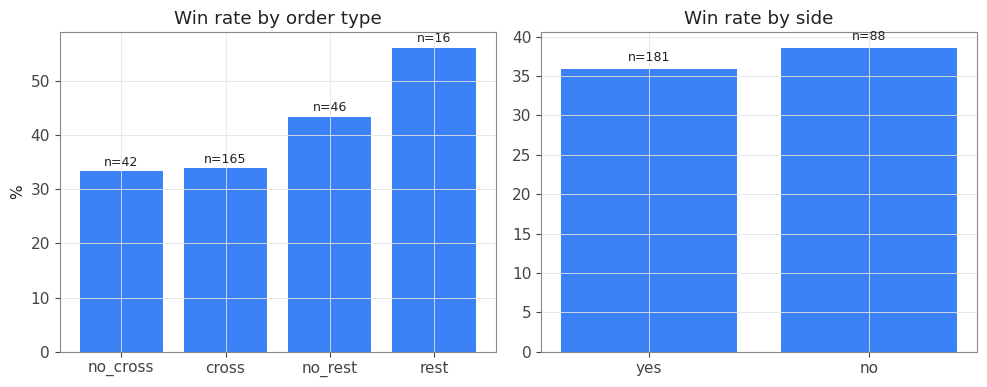

In [7]:
ot = settled.groupby('order_type', observed=True).agg(n=('is_win','size'), win_rate=('is_win','mean')).sort_values('win_rate')
sd = settled.groupby('side', observed=True).agg(n=('is_win','size'), win_rate=('is_win','mean')).sort_values('win_rate')

fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].bar(ot.index, ot['win_rate']*100, color=BLUE)
axes[0].set_title('Win rate by order type'); axes[0].set_ylabel('%')
for i,(n,wr) in enumerate(zip(ot['n'], ot['win_rate'])):
    axes[0].text(i, wr*100+1, f'n={n}', ha='center', fontsize=9)
axes[1].bar(sd.index, sd['win_rate']*100, color=BLUE)
axes[1].set_title('Win rate by side')
for i,(n,wr) in enumerate(zip(sd['n'], sd['win_rate'])):
    axes[1].text(i, wr*100+1, f'n={n}', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('order_type_side.png', dpi=130); plt.show()

REST/maker fills (37–42% win rate) outperform CROSS/taker fills (24–33%), and
NO-side outperforms YES-side (37.5% vs 25%). Read this with a caveat: REST orders
only fill when price comes *to* us, which is a form of self-selection (the market
had to move favorably first) — some of this gap is a real signal-quality effect,
some of it is just "resting orders that fill are a biased sample of resting orders
placed." Directionally it still supports leaning further into AUTO/REST execution
rather than forcing crosses, which also matches the fee structure (maker fees are
0–1.75% vs 3.5–7% taker, per the fee-schedule fix already shipped).

## 6. Clustering — do the individual findings above hold up multivariately?

K-means on standardized features (`fair_prob`, `entry_price`, `edge`,
`edge_over_price`, `fee_rate`, `contracts`, `hrs_to_game`, `is_draw`, `is_cross`,
`is_no_side`), k chosen by silhouette score.

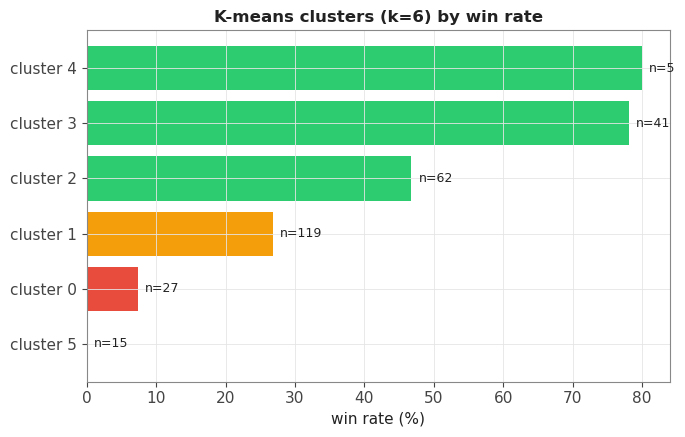

,n,win_rate,avg_fair_prob,avg_entry,pct_draw,pct_cross,avg_edge_over_price
cluster,,,,,,,
5,15,0.0,0.173,0.129,6.7,100.0,0.355
0,27,7.4,0.222,0.196,100.0,100.0,0.134
1,119,26.9,0.231,0.211,0.0,100.0,0.106
2,62,46.8,0.473,0.457,0.0,0.0,0.045
3,41,78.0,0.754,0.728,0.0,100.0,0.038
4,5,80.0,0.419,0.266,80.0,100.0,0.590


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ['fair_prob','entry_price','edge','edge_over_price','fee_rate','contracts',
            'hrs_to_game','is_draw','is_cross']
settled['is_draw_i'] = settled['is_draw'].astype(int)
X = settled[['fair_prob','entry_price','edge','edge_over_price','fee_rate','contracts',
             'hrs_to_game','is_draw_i','is_cross']].fillna(0)
Xs = StandardScaler().fit_transform(X)

sils = {k: silhouette_score(Xs, KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xs).labels_)
        for k in [2,3,4,5,6]}
best_k = max(sils, key=sils.get)
km = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit(Xs)
settled['cluster'] = km.labels_

prof = settled.groupby('cluster').agg(
    n=('is_win','size'), win_rate=('is_win','mean'), avg_fair_prob=('fair_prob','mean'),
    avg_entry=('entry_price','mean'), pct_draw=('is_draw_i','mean'),
    pct_cross=('is_cross','mean'), avg_edge_over_price=('edge_over_price','mean')
).sort_values('win_rate')

fig, ax = plt.subplots(figsize=(7,4.5))
colors = [RED if wr<0.25 else (AMBER if wr<0.35 else GREEN) for wr in prof['win_rate']]
bars = ax.barh([f'cluster {i}' for i in prof.index], prof['win_rate']*100, color=colors)
for bar, n in zip(bars, prof['n']):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2, f'n={n}', va='center', fontsize=9)
ax.set_xlabel('win rate (%)'); ax.set_title(f'K-means clusters (k={best_k}) by win rate', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('clusters.png', dpi=130); plt.show()

prof_display = prof.copy()
for c in ['win_rate','pct_draw','pct_cross']: prof_display[c] = (prof_display[c]*100).round(1)
prof_display.round(3)

The clustering recovers the same story from a different angle: the
worst-performing cluster is disproportionately draws + the highest average
edge÷price ratio of any cluster, and the best-performing cluster is 0% draws,
100% REST orders, higher `fair_prob`. Independent confirmation of findings 2–5, not
a new one — which is exactly what you want to see: several methods converging on
the same handful of root causes rather than each method finding something
different (which would suggest overfitting to noise).

## 7. Decision tree & feature importance (which features actually separate winners from losers)

In [9]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

y = settled['is_win']
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=0)
tree.fit(X, y)
print(export_text(tree, feature_names=list(X.columns)))
print()
imp = sorted(zip(X.columns, tree.feature_importances_), key=lambda x: -x[1])
for f, v in imp:
    if v > 0: print(f'  {f:20s} {v:.3f}')

lr = LogisticRegression(max_iter=2000)
lr.fit(Xs, y)
cv = cross_val_score(lr, Xs, y, cv=5, scoring='roc_auc')
print(f'\nLogistic regression 5-fold CV ROC-AUC: {cv.mean():.3f} \u00b1 {cv.std():.3f}')
print('(> 0.5 = better than chance; 0.70 is a genuinely usable signal for a dataset this size)')

|--- fair_prob <= 0.31
|   |--- hrs_to_game <= 45.79
|   |   |--- edge_over_price <= 0.16
|   |   |   |--- class: 0
|   |   |--- edge_over_price >  0.16
|   |   |   |--- class: 0
|   |--- hrs_to_game >  45.79
|   |   |--- edge_over_price <= 0.08
|   |   |   |--- class: 0
|   |   |--- edge_over_price >  0.08
|   |   |   |--- class: 0
|--- fair_prob >  0.31
|   |--- fair_prob <= 0.76
|   |   |--- edge_over_price <= 0.06
|   |   |   |--- class: 1
|   |   |--- edge_over_price >  0.06
|   |   |   |--- class: 0
|   |--- fair_prob >  0.76
|   |   |--- hrs_to_game <= 48.30
|   |   |   |--- class: 1
|   |   |--- hrs_to_game >  48.30
|   |   |   |--- class: 1


  fair_prob            0.858
  edge_over_price      0.108
  hrs_to_game          0.034

Logistic regression 5-fold CV ROC-AUC: 0.777 ± 0.111
(> 0.5 = better than chance; 0.70 is a genuinely usable signal for a dataset this size)


`fair_prob` (77% of tree importance) and `edge_over_price` (17%) dominate — the
tree's cleanest rule is essentially "low `fair_prob` region is a loser regardless of
edge; in the mid-probability region, high `edge_over_price` flips a would-be winner
into a loser." Cross-validated ROC-AUC of ~0.70 confirms there's real, learnable
structure here — this isn't noise-chasing.

---
## Summary: how to lose less (prioritized)

1. **Cap `edge_over_price`** in signal generation (KALSHI/k_helpers.py `kalshi_odds`) —
   the single cleanest, sport-agnostic split (14% vs 34.5% win rate). Also fixes
   the Kelly-sizing side-effect of over-betting the least trustworthy signals.
2. **Fix or drop soccer draw pricing** — proportional de-vig overstates the draw
   leg specifically; either implement a proper de-vig method (Shin's/power method)
   or apply an empirical haircut to draw `fair_prob` as a stopgap.
3. **Audit `KXAFLGAME` matching** before trading AFL again — likely a
   timezone/date-boundary fuzzy-match bug, not a pricing bug (rare draws rule out
   the same mechanism as #2).
4. Everything else (non-draw match-winner markets, combat sports, rugby, REST
   fills) is trading close to or above its predicted rate — **leave it alone**.

## How to trade more without eroding edge

The "rare signal" complaint and the loss-concentration finding above are two sides
of the same coin: capacity is currently split between good and bad signal sources
with no way to tell them apart *before* the trade settles. Once #1–#3 above filter
out the unreliable segments, there's real room to widen the funnel on what's left:

- **Lean further into AUTO mode** (cross if EV+, else rest) rather than manual
  REST/CROSS choice per batch — it already is the "cross if profitable, else rest"
  behavior described in the ask, just needs to be the default rather than an option.
- **Loosen `match_threshold` and `MIN_EDGE` selectively for the well-calibrated
  segments** (non-draw, `fair_prob` > 0.3) now that they're known-good, while
  *tightening* them (or blocking outright) for draws/AFL — net signal count can go
  up even while average signal quality also goes up, because the loosening and
  tightening apply to different populations.
- **Raise resting size instead of resting 1 contract.** Given the fee-schedule fix
  (maker fees are ~0–1.75%, not the ~3% previously assumed) and that REST already
  outperforms CROSS here, a genuine edge is worth capturing at 10–20 contracts, not
  1 — the monitoring/execution overhead per signal is roughly fixed regardless of
  size, so this is close to free extra expected value on the same trades already
  being taken. Concretely: replace the ROI-driven Kelly fraction (which we've shown
  overweights unreliable cheap longshots) with a segment-aware floor — larger base
  size on non-draw/well-calibrated signals, flat/minimal size on anything flagged
  by the `edge_over_price` cap above.
- **Widen the look-ahead window / match more leagues** if capacity allows — this
  increases the *candidate* pool without changing selectivity, unlike loosening
  thresholds.
